<a href="https://colab.research.google.com/github/francalassa/analisador-noticias-ia/blob/main/relatorio_final_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import userdata # Ferramenta de segurança do Google
import google.generativeai as genai
import requests
import pandas as pd

# 1. SEGURANÇA: Buscando as chaves nos Secrets
try:
    CHAVE_GEMINI = userdata.get('GEMINI_API_KEY')
    CHAVE_NEWS = userdata.get('NEWS_API_KEY')
    genai.configure(api_key=CHAVE_GEMINI)
    print("✅ Chaves de API carregadas com segurança!")
except Exception as e:
    print("❌ Erro: Configure as chaves no ícone 🔑 do menu lateral!")

# 2. Buscar Notícias Reais
url = f'https://newsapi.org/v2/everything?q=Inteligência Artificial&language=pt&apiKey={CHAVE_NEWS}'
artigos = requests.get(url).json().get('articles', [])

# 3. Identificar Modelo e Processar
modelos = [m.name for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]
model = genai.GenerativeModel(modelos[0])

resultados = []
print(f"🤖 Iniciando análise com {modelos[0]}...")

for noticia in artigos:
    titulo = noticia['title']
    link = noticia['url'] # Pegando o link aqui
    data = noticia['publishedAt']

    try:
        # Pedindo apenas a palavra-chave para facilitar a limpeza
        prompt = f"Responda apenas com UMA PALAVRA (Positivo, Negativo ou Neutro) o sentimento desta notícia: {titulo}"
        response = model.generate_content(prompt)
        sentimento = response.text.strip().upper()

        # Guardando TUDO, inclusive o Link
        resultados.append({
            'Data': data,
            'Titulo': titulo,
            'Sentimento': sentimento,
            'Link': link
        })
        print(f"✅ Processado: {titulo[:30]}...")
    except:
        continue

# 4. Gerar Tabela e Salvar CSV
if resultados:
    df_final = pd.DataFrame(resultados)

    # Salva o arquivo para download
    df_final.to_csv('relatorio_final_ia.csv', index=False, encoding='utf-8-sig')

    print("\n Tabela gerada com sucesso.")
    display(df_final)
else:
    print("❌ Erro: Nenhum dado foi processado.")


✅ Chaves de API carregadas com segurança!
🤖 Iniciando análise com models/gemini-2.5-flash...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1215.39ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1038.58ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2127.54ms


✅ Processado: Como a inteligência artificial...
✅ Processado: Por que a inteligência artific...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1468.79ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 811.29ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 3087.80ms


✅ Processado: Gadgets como iPhone e PS5 estã...


✅ Processado: Apple prepara “selo de autenti...
✅ Processado: Cursor lança plataforma de alo...
✅ Processado: Estudantes, a Google está a of...
✅ Processado: Revolut lança divisão dedicada...


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 50937.55ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1114.15ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 810.84ms
ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 1063.36ms



 Tabela gerada com sucesso.


,Data,Titulo,Sentimento,Link
0,2026-08-26T20:30:00Z,Como a inteligência artificial foi “descoberta...,POSITIVO,https://olhardigital.com.br/2026/08/26/intelig...
1,2026-08-27T09:15:00Z,Por que a inteligência artificial importa? Ent...,POSITIVO,https://olhardigital.com.br/2026/08/27/intelig...
2,2026-08-17T12:00:15Z,Gadgets como iPhone e PS5 estão cada vez mais ...,NEGATIVO,https://pplware.sapo.pt/gadgets/gadgets-como-i...
3,2026-08-12T21:30:06Z,Apple prepara “selo de autenticidade” para pro...,POSITIVO,https://pplware.sapo.pt/apple/apple-prepara-se...
4,2026-08-19T20:30:01Z,Cursor lança plataforma de alojamento de códig...,POSITIVO,https://pplware.sapo.pt/software/cursor-lanca-...
5,2026-08-20T16:54:14Z,"Estudantes, a Google está a oferecer um ano de...",POSITIVO,https://pplware.sapo.pt/inteligencia-artificia...
6,2026-08-25T08:59:54Z,Revolut lança divisão dedicada à investigação ...,POSITIVO,https://pplware.sapo.pt/informacao/revolut-lan...


In [13]:
from google.colab import files

# Comando para forçar o download direto para o PC
try:
    files.download('relatorio_final_ia.csv')
    print("Janela de download aberta!")
except:
    print("❌ O arquivo ainda não foi gerado ou o navegador bloqueou o pop-up.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Janela de download aberta!


In [14]:
# Lista de termos que nos interessam
termos_importantes = ["Nvidia", "OpenAI", "Google", "Brasil", "Microsoft", "Meta", "Apple", "ChatGPT", "Tecnologia", "Mercado", "Governo", "Investimento"]

noticias_filtradas = []

# O 'for' significa "PARA cada". Ele vai repetir o que estiver abaixo dele.
for noticia in artigos:
    titulo = noticia['title']

    # O 'any' verifica se QUALQUER palavra da nossa lista está no título
    if any(termo.lower() in titulo.lower() for termo in termos_importantes):

        # Este 'print' está RECUADO (identado).
        # Isso diz ao Python: "Só execute isso SE o 'if' lá de cima for verdadeiro"
        print(f"🎯 Relevante: {titulo}")
        noticias_filtradas.append(noticia)
    else:
        # O 'else' é o "CASO CONTRÁRIO". Se não achou o termo, ele cai aqui.
        print(f"⚪ Ignorada: {titulo[:30]}...")

# Criando o DataFrame (df) apenas com o que filtramos
df_filtrado = pd.DataFrame(noticias_filtradas)

⚪ Ignorada: Como a inteligência artificial...
⚪ Ignorada: Por que a inteligência artific...
⚪ Ignorada: Inteligência artificial em cin...
⚪ Ignorada: Como o Olhar Digital acompanha...
⚪ Ignorada: Alibaba quer investir US$ 10,2...
⚪ Ignorada: Vigiar os “pensamentos” da int...
⚪ Ignorada: EUA apertam o cerco à China e ...
⚪ Ignorada: YouTube expande acesso ao Ask ...
⚪ Ignorada: O perigo oculto da inteligênci...
🎯 Relevante: Google faz mudanças e troca chefes de divisão de inteligência artificial
⚪ Ignorada: Claude fica fora do ar nesta t...
🎯 Relevante: Lula anuncia investimentos de R$ 2,3 bilhões em inteligência artificial
⚪ Ignorada: TCL lança o tablet intermediár...
⚪ Ignorada: Zerezes lança coleção “Miragem...
⚪ Ignorada: Os livros que passaram décadas...
⚪ Ignorada: SpaceX encara teste decisivo c...
🎯 Relevante: DeepSeek mostra que IA mais barata pode ganhar espaço no mercado
⚪ Ignorada: Data center de IA ameaça desre...
🎯 Relevante: SpaceX acelera corrida da IA, mas mercado freia 

In [15]:
analise_vips = []

for noticia in noticias_filtradas:
    texto_para_ia = noticia['title']

    try:
        prompt = f"Analise o sentimento desta notícia em uma palavra (Positivo/Negativo/Neutro): {texto_para_ia}"

        # TROCAMOS 'client.models.generate_content' por 'model.generate_content'
        resposta = model.generate_content(prompt)

        sentimento = resposta.text.strip()

        analise_vips.append({
            "Título": texto_para_ia,
            "Sentimento": sentimento,
            "Fonte": noticia['url']
        })
        print(f"✅ Analisado com sucesso: {texto_para_ia[:30]}...")

    except Exception as erro:
        print(f"❌ Erro ao analisar: {erro}")

df_vips = pd.DataFrame(analise_vips)

❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 55.658596793s.


ERROR:tornado.access:503 POST /v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 2051.35ms


❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 52.412235831s.


❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 51.988184364s.


❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 51.532089299s.


...

❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 38.686461058s.


❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 38.238435388s.


❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 37.836804068s.


❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 37.422893775s.


❌ Erro ao analisar: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 37.000631781s.


In [16]:
# 1. Instalamos a biblioteca nova (se der erro de 'no module found', rode esta linha)
!pip install -q -U google-genai

# 2. Importamos o 'genai' da biblioteca nova
from google import genai
from google.colab import userdata

# 3. Pegamos a chave dos Secrets (🔑)
CHAVE_GEMINI = userdata.get('GEMINI_API_KEY')

# 4. Criamos o CLIENT (o novo 'garçom' oficial da Google)
client = genai.Client(api_key=CHAVE_GEMINI)

print("🚀 Sistema atualizado para a versão 2026!")

🚀 Sistema atualizado para a versão 2026!


In [17]:
import time

resultados_finais = []

for noticia in noticias_filtradas:
    texto = noticia['title']

    try:
        # Usando o nome EXATO que apareceu na sua lista
        resposta = client.models.generate_content(
            model="models/gemini-2.0-flash",
            contents=f"Analise o sentimento desta notícia em UMA PALAVRA (Positivo/Negativo/Neutro): {texto}"
        )

        sentimento = resposta.text.strip()

        resultados_finais.append({
            "Data": noticia.get('publishedAt', 'N/A')[:10],
            "Título": texto,
            "Sentimento": sentimento,
            "Link": noticia['url']
        })
        print(f"✅ Analisado: {texto[:40]}... -> {sentimento}")

        # O "soninho" de 5 segundos para não esgotar a cota
        time.sleep(40)

    except Exception as e:
        if "429" in str(e):
            print("⏳ Limite atingido! O Google pediu uma pausa de 30 segundos...")
            time.sleep(30)
        else:
            print(f"❌ Erro na notícia: {texto[:20]} | Erro: {e}")

# Exibe a tabela final
import pandas as pd
df_vips = pd.DataFrame(resultados_finais)
df_vips

❌ Erro na notícia: Google faz mudanças  | Erro: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.0-flash is no longer available. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.', 'status': 'NOT_FOUND'}}
❌ Erro na notícia: Lula anuncia investi | Erro: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.0-flash is no longer available. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.', 'status': 'NOT_FOUND'}}
❌ Erro na notícia: DeepSeek mostra que  | Erro: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'This model models/gemini-2.0-flash is no longer available. Please update your code to use models/gemini-3.6-flash for the latest features and improvements. We recommend you to use the Interactions API.', 'status': 'NOT_FOUND'}}
❌ Erro na notícia: 

""


In [18]:
# Lista de todos os modelos que o 'client' pode usar
for m in client.models.list():
    print(f"Nome do modelo: {m.name}")

Nome do modelo: models/gemini-2.5-flash
Nome do modelo: models/gemini-2.5-pro
Nome do modelo: models/gemini-2.5-flash-preview-tts
Nome do modelo: models/gemini-2.5-pro-preview-tts
Nome do modelo: models/gemini-flash-latest-high-res-exp
Nome do modelo: models/gemma-4-26b-a4b-it
Nome do modelo: models/gemma-4-31b-it
Nome do modelo: models/gemini-flash-latest
Nome do modelo: models/gemini-flash-lite-latest
Nome do modelo: models/gemini-pro-latest
Nome do modelo: models/gemini-2.5-flash-lite
Nome do modelo: models/gemini-2.5-flash-image
Nome do modelo: models/gemini-3-flash-preview
Nome do modelo: models/gemini-3.1-pro-preview
Nome do modelo: models/gemini-3.1-pro-preview-customtools
Nome do modelo: models/gemini-3.1-flash-lite-preview
Nome do modelo: models/gemini-3.1-flash-lite
Nome do modelo: models/gemini-3-pro-image-preview
Nome do modelo: models/gemini-3-pro-image
Nome do modelo: models/nano-banana-pro-preview
Nome do modelo: models/gemini-3.1-flash-image-preview
Nome do modelo: mode

In [19]:
# Instalando a biblioteca de nuvem de palavras
!pip install -q wordcloud

import matplotlib.pyplot as plt
from wordcloud import WordCloud

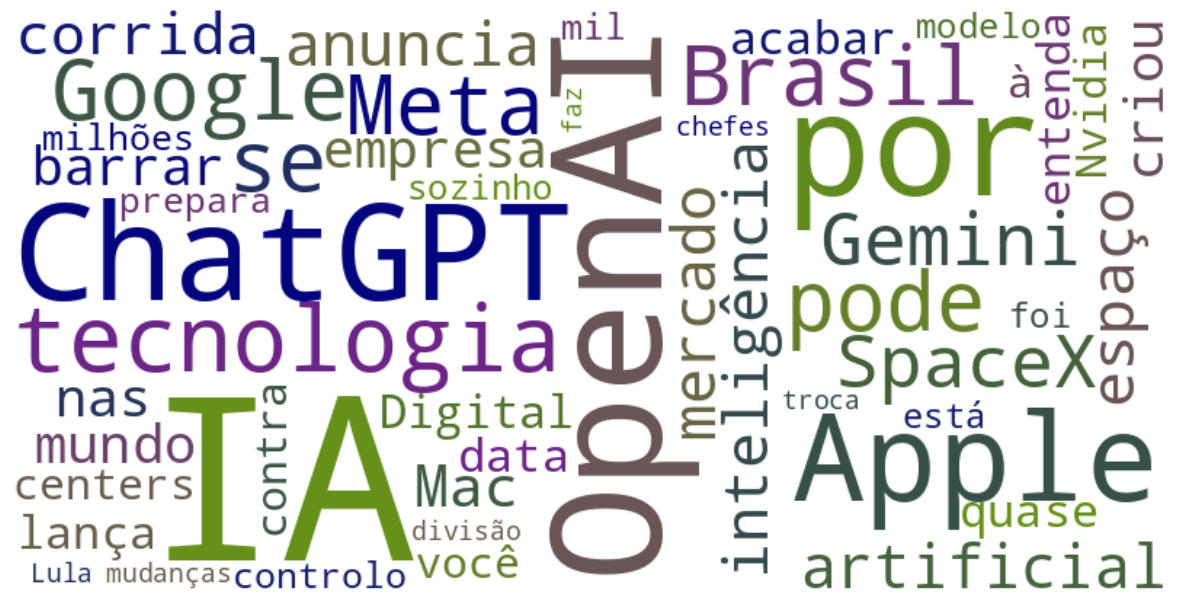

In [20]:
# 1. Juntando todos os títulos em uma única string (texto)
todo_o_texto = " ".join([noticia['title'] for noticia in noticias_filtradas])

# 2. Definido palavras para IGNORAR (Stopwords)
# Adicionar algumas em português que a biblioteca costuma pular
palavras_irrelevantes = ["de", "a", "o", "que", "e", "do", "da", "em", "um", "para", "com", "não", "uma", "os", "as", "no", "na", "mais"]

# 3. Configurando a Nuvem
from matplotlib.colors import LinearSegmentedColormap

# Escolha as cores em Hexadecimal ou nomes em inglês
# Exemplo: Azul Marinho, Verde e Roxo
minhas_cores = ["#000080", "#659119", "#6D1991"]
mapa_personalizado = LinearSegmentedColormap.from_list("custom", minhas_cores)

nuvem = WordCloud(
    width=800,
    height=400,
    background_color='white', # Branco costuma ser mais profissional para slides
    stopwords=palavras_irrelevantes,
    colormap=mapa_personalizado, # Usando suas cores!
    max_words=50
).generate(todo_o_texto)

plt.figure(figsize=(15, 8))
plt.imshow(nuvem, interpolation='bilinear')
plt.axis('off')
plt.show()

In [23]:
import numpy as np
from PIL import Image

# 1. Cole o caminho do arquivo aqui, entre aspas
caminho_do_molde = "/content/Silhueta Brasil (2).png"

# 2. Abrimos a imagem e garantimos que ela esteja no modo correto (RGB)
imagem_pil = Image.open(caminho_do_molde).convert("RGB")

# 3. Transformamos a imagem em uma "matriz" que o Python entende
mascara_original = np.array(imagem_pil)

""" --- A MÁGICA DO MOLDE ---
 Vamos criar uma CÓPIA exata da matriz para não mexer na original"""
mascara_brasil = mascara_original.copy()

""" O WordCloud só aceita o valor '254' (branco puro) como fundo ignorado.
 Qualquer outra coisa é tratada como molde para desenhar.

 Varremos a imagem pixel por pixel:"""
for i in range(len(mascara_brasil)):
    for j in range(len(mascara_brasil[i])):
        # Se o pixel NÃO for branco puro (254, 254, 254),
        # nós forçamos ele a ser PRETO puro (0, 0, 0).
        if not np.array_equal(mascara_brasil[i][j], [0, 0, 0]):
            mascara_brasil[i][j] = [255, 255, 255] # Transforma em Preto Puro (para desenhar)
        # Se já for branco, garantimos que seja o branco puro correto
        else:
            mascara_brasil[i][j] = [0, 0, 0] # Transforma em Branco Puro (para ignorar)
# ----------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

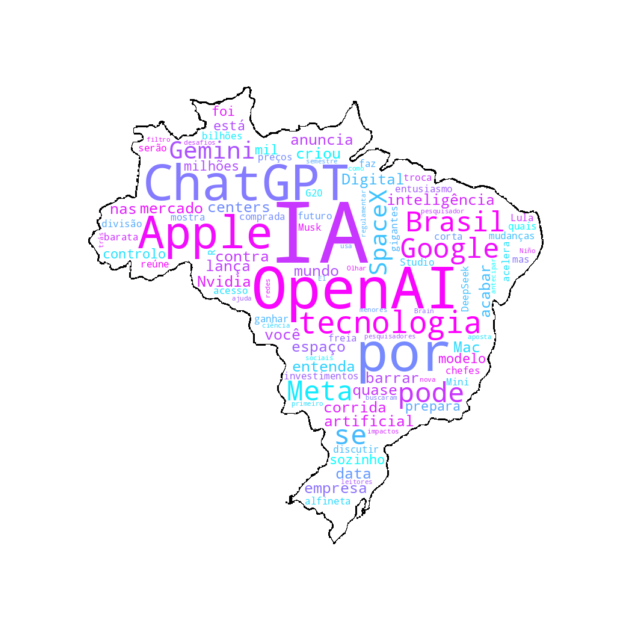

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Definimos Stopwords (palavras para ignorar)
# Adicione mais palavras se você notar que elas estão roubando o brilho das importantes
palavras_irrelevantes = ["de", "a", "o", "que", "e", "do", "da", "em", "um", "para", "com", "não", "uma", "os", "as", "no", "na", "mais", "ao", "à", "dos", "das"]

# Criamos a Nuvem usando a MÁSCARA
nuvem_formato = WordCloud(
    background_color="white", # Fundo branco para destacar as cores
    mask=mascara_brasil,      # <-- Imagem Formato do Brasil
    stopwords=palavras_irrelevantes,
    colormap='cool',          # Paleta de cores (Azul e Rosa)
    contour_width=1,          # Adiciona um contorno fino na forma
    contour_color='black',    # Cor do contorno
    max_words=100             # Número de palavras para preencher o formato
).generate(todo_o_texto)

# Exibimos o resultado
plt.figure(figsize=(8, 8))
plt.imshow(nuvem_formato, interpolation='bilinear')
plt.axis("off")
plt.show()

In [25]:
import pandas as pd

# Transformando a lista de dicionários em uma tabela (DataFrame)
df = pd.DataFrame(noticias_filtradas)

# Selecionando apenas as colunas que interessam para o nosso relatório
df_clean = df[['publishedAt', 'source', 'title', 'url']].copy()

# Renomeando as colunas para ficar em Português e bonito
df_clean.columns = ['Data', 'Fonte', 'Título', 'Link']

# Ajustando a data para o formato brasileiro (DD/MM/AAAA)
df_clean['Data'] = pd.to_datetime(df_clean['Data']).dt.strftime('%d/%m/%Y')

# Extraindo apenas o nome da fonte (limpando o dicionário da NewsAPI)
df_clean['Fonte'] = df_clean['Fonte'].apply(lambda x: x['name'] if isinstance(x, dict) else x)

# Exibe as primeiras 10 linhas da sua tabela organizada
df_clean.head(10)

,Data,Fonte,Título,Link
0,05/08/2026,Tecnoblog.net,Google faz mudanças e troca chefes de divisão ...,https://tecnoblog.net/noticias/google-faz-muda...
1,21/08/2026,Abril.com.br,"Lula anuncia investimentos de R$ 2,3 bilhões e...",https://veja.abril.com.br/economia/lula-anunci...
2,03/08/2026,Olhardigital.com.br,DeepSeek mostra que IA mais barata pode ganhar...,https://olhardigital.com.br/2026/08/03/intelig...
3,05/08/2026,Olhardigital.com.br,"SpaceX acelera corrida da IA, mas mercado frei...",https://olhardigital.com.br/2026/08/05/pro/spa...
4,26/08/2026,Olhardigital.com.br,Apple: quais serão os preços do Mac Mini e do ...,https://olhardigital.com.br/2026/08/26/reviews...
5,29/08/2026,Olhardigital.com.br,OpenAI corta acesso de empresa comprada por Sp...,https://olhardigital.com.br/2026/08/29/intelig...
6,27/08/2026,Olhardigital.com.br,G20 reúne gigantes da tecnologia para discutir...,https://olhardigital.com.br/2026/08/27/pro/g20...
7,06/08/2026,Olhardigital.com.br,O pesquisador por trás do Google Brain criou u...,https://olhardigital.com.br/2026/08/06/intelig...
8,03/08/2026,Olhardigital.com.br,IA ajuda pesquisadores a antecipar impactos do...,https://olhardigital.com.br/2026/08/03/ciencia...
9,13/08/2026,Olhardigital.com.br,Meta usa IA como filtro para barrar menores na...,https://olhardigital.com.br/2026/08/13/interne...


In [26]:
import pandas as pd

# 1. Tentamos localizar onde os dados foram parar
lista_de_seguranca = []

if 'noticias_filtradas' in locals() and len(noticias_filtradas) > 0:
    lista_de_seguranca = noticias_filtradas
elif 'articles' in locals(): # Algumas versões da API salvam direto aqui
    lista_de_seguranca = articles
else:
    print("❌ Xi... as variáveis parecem vazias. Vamos precisar rodar a busca da NewsAPI de novo!")

# 2. Se achamos algo, transformamos em tabela SEM frescuras
if lista_de_seguranca:
    df_final = pd.DataFrame(lista_de_seguranca)

    # Tratamento simplificado para não dar erro de 'dict'
    if 'source' in df_final.columns:
        df_final['Veículo'] = df_final['source'].apply(lambda x: x['name'] if isinstance(x, dict) else x)

    # Selecionar apenas o básico para não poluir
    colunas_disponiveis = [c for c in ['publishedAt', 'Veículo', 'title', 'url'] if c in df_final.columns]
    tabela_exibicao = df_final[colunas_disponiveis].copy()

    print(f"✅ CONSEGUIMOS! Exibindo {len(tabela_exibicao)} notícias encontradas.")
    display(tabela_exibicao)
else:
    print("⚠️ Nenhuma notícia encontrada na memória. Rode a célula da URL (requests.get) e tente este código logo em seguida!")

✅ CONSEGUIMOS! Exibindo 37 notícias encontradas.


,publishedAt,Veículo,title,url
0,2026-08-05T20:57:21Z,Tecnoblog.net,Google faz mudanças e troca chefes de divisão ...,https://tecnoblog.net/noticias/google-faz-muda...
1,2026-08-21T11:29:44Z,Abril.com.br,"Lula anuncia investimentos de R$ 2,3 bilhões e...",https://veja.abril.com.br/economia/lula-anunci...
2,2026-08-03T11:02:46Z,Olhardigital.com.br,DeepSeek mostra que IA mais barata pode ganhar...,https://olhardigital.com.br/2026/08/03/intelig...
3,2026-08-05T12:11:32Z,Olhardigital.com.br,"SpaceX acelera corrida da IA, mas mercado frei...",https://olhardigital.com.br/2026/08/05/pro/spa...
4,2026-08-26T11:15:30Z,Olhardigital.com.br,Apple: quais serão os preços do Mac Mini e do ...,https://olhardigital.com.br/2026/08/26/reviews...
5,2026-08-29T18:23:19Z,Olhardigital.com.br,OpenAI corta acesso de empresa comprada por Sp...,https://olhardigital.com.br/2026/08/29/intelig...
6,2026-08-27T15:17:50Z,Olhardigital.com.br,G20 reúne gigantes da tecnologia para discutir...,https://olhardigital.com.br/2026/08/27/pro/g20...
7,2026-08-06T11:43:34Z,Olhardigital.com.br,O pesquisador por trás do Google Brain criou u...,https://olhardigital.com.br/2026/08/06/intelig...
8,2026-08-03T18:59:00Z,Olhardigital.com.br,IA ajuda pesquisadores a antecipar impactos do...,https://olhardigital.com.br/2026/08/03/ciencia...
9,2026-08-13T10:32:58Z,Olhardigital.com.br,Meta usa IA como filtro para barrar menores na...,https://olhardigital.com.br/2026/08/13/interne...


In [27]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# --- CONFIGURAÇÃO DIRETA ---
MINHA_CHAVE = 'SUA_CHAVE_AQUI' # Coloque sua chave aqui!
termo_busca = 'Brasil'
url_noticias = f'https://newsapi.org/v2/everything?q={termo_busca}&language=pt&apiKey={MINHA_CHAVE}'

# --- BUSCA OS DADOS ---
try:
    resposta = requests.get(url_noticias)
    dados_brutos = resposta.json()
    lista_artigos = dados_brutos.get('articles', [])

    if len(lista_artigos) > 0:
        # --- CRIA A TABELA ---
        df_limpo = pd.DataFrame(lista_artigos)
        df_limpo['Fonte'] = df_limpo['source'].apply(lambda x: x['name'] if isinstance(x, dict) else x)

        print(f"✅ CONSEGUIMOS! {len(df_limpo)} notícias na tabela.")
        display(df_limpo[['publishedAt', 'Fonte', 'title']].head(15))

        # --- CRIA A NUVEM (SIMPLES) ---
        texto = " ".join(df_limpo['title'])
        nuvem = WordCloud(background_color="white", width=800, height=400).generate(texto)

        plt.figure(figsize=(10, 5))
        plt.imshow(nuvem, interpolation='bilinear')
        plt.axis("off")
        plt.show()
    else:
        print("🤔 A API respondeu, mas não encontrou notícias com esse termo.")

except Exception as e:
    print(f"❌ Erro ao rodar: {e}")

🤔 A API respondeu, mas não encontrou notícias com esse termo.
